In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

In [ ]:
iris = load_iris()
x = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = pd.DataFrame(data=iris.target, columns=['y'])

In [ ]:
df = x

In [ ]:
df['y'] = y

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
x = df.loc[:, df.columns!='y']

In [ ]:
def z_scale(df):
    neo_df = df.copy()

    for col in df.columns:
        neo_df[col] = (neo_df[col] - neo_df[col].mean())/neo_df[col].std()

    return neo_df

In [ ]:
x_z = z_scale(x)

In [ ]:
x_z.insert(0, 'x0', 1)

In [ ]:
x_z

,x0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,1,-0.897674,1.015602,-1.335752,-1.311052
1,1,-1.139200,-0.131539,-1.335752,-1.311052
2,1,-1.380727,0.327318,-1.392399,-1.311052
3,1,-1.501490,0.097889,-1.279104,-1.311052
4,1,-1.018437,1.245030,-1.335752,-1.311052
...,...,...,...,...,...
145,1,1.034539,-0.131539,0.816859,1.443994
146,1,0.551486,-1.278680,0.703564,0.919223
147,1,0.793012,-0.131539,0.816859,1.050416
148,1,0.430722,0.786174,0.930154,1.443994


In [ ]:
import numpy as np
import cv2

In [ ]:
noise = cv2.randn(np.zeros([256, 256]).astype(np.uint8), 0, 255)

In [ ]:
import matplotlib.pyplot as plt

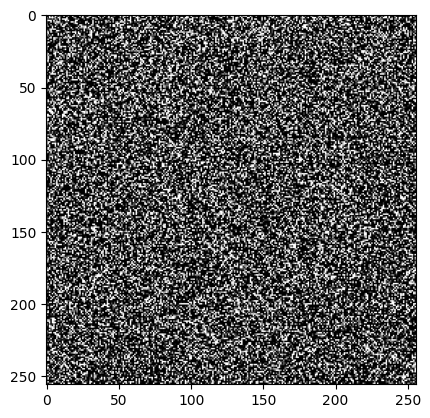

In [ ]:
plt.imshow(noise, cmap='gray')

In [ ]:
# backprops

## Perceptron, Sigmoid Neuron - W = W + eta* (y_true-y_hat)*x_vector
## Softmax - W = W - eta * (sfmax_prob-oh_vec_rep)*x_vector

In [ ]:
import tensorflow as tf

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

gray_scale = 255
x_train /= gray_scale
x_test /= gray_scale

<Figure size 2800x2800 with 0 Axes>

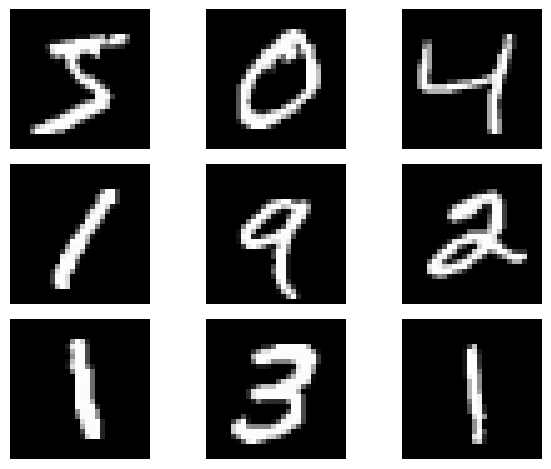

In [ ]:
plt.figure(figsize = (28, 28))

fig, ax = plt.subplots(3, 3)
k = 0

for i in range(3):
    for j in range(3):
      ax[i][j].axis("off"), ax[i][j].imshow(x_train[k].reshape(28, 28), cmap='gray')
      k += 1

plt.tight_layout()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=10, batch_size=2000, validation_split=0.2)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.5839 - loss: 1.5427 - val_accuracy: 0.8921 - val_loss: 0.3703
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.8970 - loss: 0.3526 - val_accuracy: 0.9233 - val_loss: 0.2601
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9269 - loss: 0.2515 - val_accuracy: 0.9391 - val_loss: 0.2125
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9418 - loss: 0.2018 - val_accuracy: 0.9500 - val_loss: 0.1795
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9516 - loss: 0.1669 - val_accuracy: 0.9548 - val_loss: 0.1616
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9575 - loss: 0.1469 - val_accuracy: 0.9570 - val_loss: 0.1494
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9649 - loss: 0.1237 - val_accuracy: 0.9623 - val_loss: 0.1327
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9699 - loss: 0.1074 - val_accuracy: 0.9641 - v

In [ ]:
model.evaluate(x_test, y_test, verbose=0)

[0.10766015946865082, 0.9678999781608582]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
def create_mlp(input_dim, output_dim, hidden_layers=[64, 32, 32], dropout_rate=0.2):
    model = Sequential()
    model.add(Dense(hidden_layers[0], input_dim=input_dim, activation='relu'))
    model.add(Dropout(dropout_rate))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))

    model.add(Dense(output_dim, activation='softmax'))
    model.compile(optimizer='SGD',
                  loss='crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
def load_data():
    from sklearn.datasets import load_iris
    data = load_iris()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.Series(data.target)
    return X, y

In [ ]:
X, y = load_data()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Mean Squared Error: 0.004549776768824917
R^2 Score: 0.9928423865266961


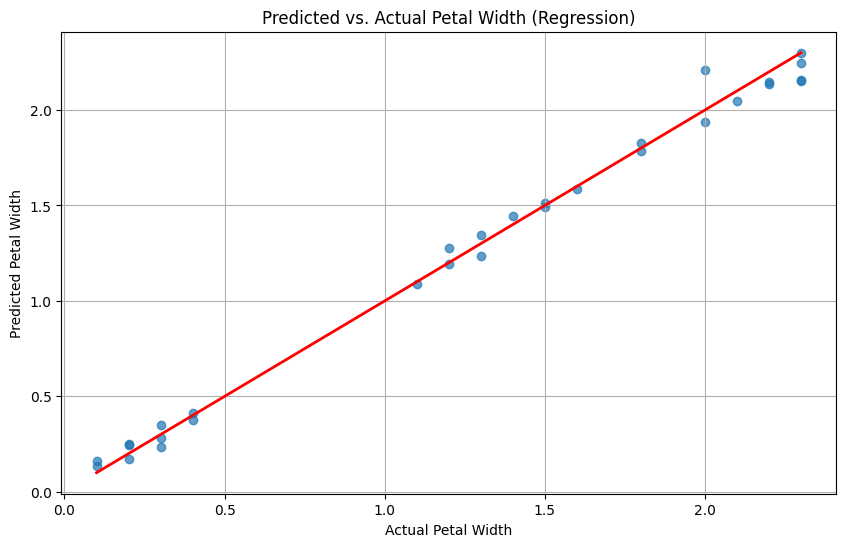

In [1]:
#9.regression using multilayer perceptron using iris dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.data[:, 3]  # Let's predict petal width (the 4th feature)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

mlp = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # Diagonal line
plt.title('Predicted vs. Actual Petal Width (Regression)')
plt.xlabel('Actual Petal Width')
plt.ylabel('Predicted Petal Width')
plt.grid(True)
plt.show()